Vitor Nishimura Vian, nUSP 5255289

Laura Fernandes Camargos, nUSP 13692334

In [ ]:
# Iniciar o Colab com R
# https://colab.research.google.com/#create=true&language=r

In [ ]:
# -----------------------------------------------------------------------------
# Installing R packages
# keras: loading mnist dataset
# -----------------------------------------------------------------------------
packages = c("keras3")
for(pkg in packages) {
  if(!(pkg %in% rownames(installed.packages()))) {
    cat("Installing: ", pkg, "\n")
    install.packages(pkg)
  }
}

In [ ]:
# -----------------------------------------------------------------------------
# Loading packages
# -----------------------------------------------------------------------------
library("keras3")

In [ ]:
# Loading Mnist dataset
mnist = dataset_mnist()

In [ ]:
# -----------------------------------------------------------------------------
# training info
# -----------------------------------------------------------------------------
trainImages = mnist$train$x
trainLabels = mnist$train$y

# -----------------------------------------------------------------------------
# testing info
# -----------------------------------------------------------------------------
testImages = mnist$test$x
testLabels = mnist$test$y

In [ ]:
# -----------------------------------------------------------------------------
# Training set dimensions
# -----------------------------------------------------------------------------
print(dim(trainImages))
print(dim(trainLabels))

# -----------------------------------------------------------------------------
# Testing Set dimensions set dimensions
# -----------------------------------------------------------------------------
print(dim(testImages))
print(dim(testLabels))

[1] 60000    28    28
[1] 60000
[1] 10000    28    28
[1] 10000


[1] 5


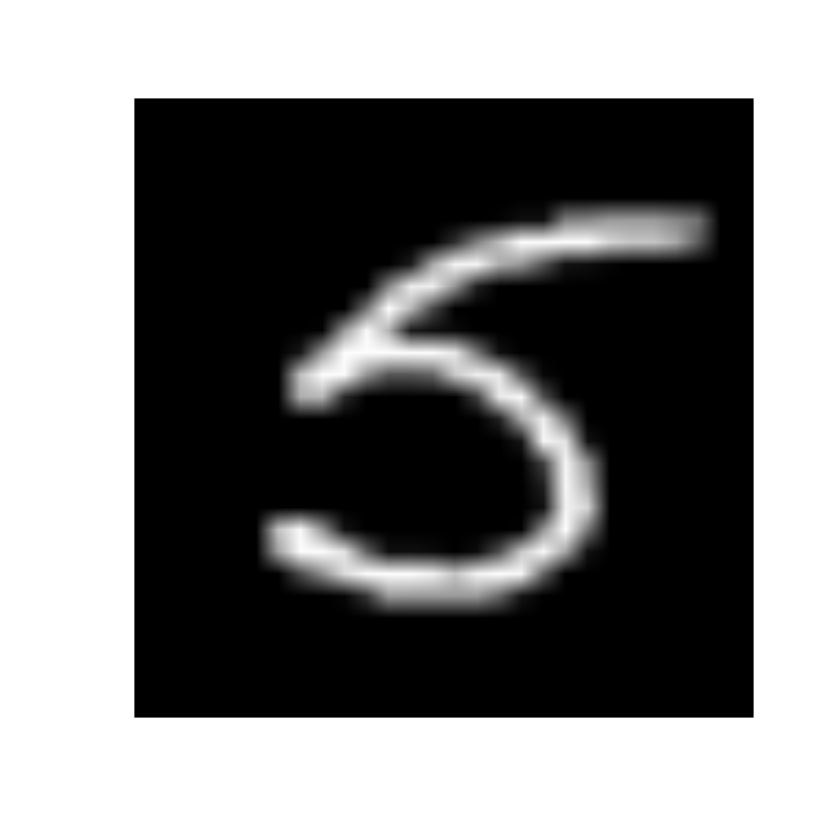

In [ ]:
# ------------------------------------------------------------------------------
# plotting first example as an image
# -----------------------------------------------------------------------------
id <- sample(60000,1)
plot(grDevices::as.raster(trainImages[id,,],max=255))
print(trainLabels[id])

In [ ]:
############ Teste Visual ###########
testa.digitos <- function(modelo, exemplos.teste, taxa.ruido = 0.1){

  taxa.ruido <- taxa.ruido # Probabilidade de um pixel ser trocado

	plotdim = 2*dim(exemplos.teste[1,,])
	plot(c(1,(plotdim[1]+5)*nrow(exemplos.teste)), c(1,(plotdim[2]+5)*3),
	          type="n", xlab="", ylab="")
	x = 1

	for (i in 1:nrow(exemplos.teste)) {
		padrao = exemplos.teste[i,,]/255 #normaliza values in [0,1]
		padrao = as.vector(ifelse(padrao >= 0.5, 1, 0))

		ruido = (runif(length(padrao), 0, 1) > taxa.ruido ) * 1
		entrada = padrao * ruido
		ret <- reconstrucao(modelo,entrada)

		# Padrao original
		img <- padrao;
		dim(img) <- dim(exemplos.teste[1,,])
		image <- as.raster((img+1)/2)
		rasterImage(image, x, 1, x + plotdim[1], plotdim[2], interpolate=F)

		# Entrada com ruido
		img <- entrada;
		dim(img) <- dim(exemplos.teste[1,,])
		image <- as.raster((img+1)/2)
		rasterImage(image, x, 1+(plotdim[2]+5), x + plotdim[1],
		            1+2*(plotdim[2]+5), interpolate=F)

		# Imagem recuperada
		img <- ret;
		dim(img) <- dim(exemplos.teste[1,,])
		image <- as.raster((img+1)/2)
		rasterImage(image, x, 1+2*(plotdim[2]+5), x + plotdim[1],
		            1+2*(plotdim[2]+5)+plotdim[2], interpolate=F)

		x = x + plotdim[1]+5
	}
}

In [ ]:
(runif(10, 0, 1) > 0.7)*1

[1] 1 1 1 1 0 0 1 0 1 1

In [ ]:
# Funcao de ativacao
funcao.ativacao <- function(v){
  y <- 1 / (1 + exp(-v))
  return(y)
}

# Funcao para amostragem
sample.bernoulli <- function(p){
  retorno <- 0

  if(runif(min=0,max=1,1) < p){
    retorno <- 1
  }

  return(retorno)
}

In [ ]:
# Funcao para construir a arquitetura
arquitetura <- function(num.visiveis, num.escondida, n, funcao.ativacao){

  arq <- list()
  arq$num.visiveis <- num.visiveis
  arq$num.escondida <- num.escondida
  arq$funcao.ativacao <- funcao.ativacao
  arq$n <- n

  # 2 neuronios na camada escondida
  #
  #     Ent1    Ent2    b
  # 1   w11     w12     w13
  # 2   w21     w22     w23

  # Pesos conectando camadas de entrada e escondida
  num.pesos.visivel.escondida <- num.visiveis * num.escondida
  arq$visivel.escondida <- matrix(runif(min=-1,max=1,num.pesos.visivel.escondida),
                                  nrow=num.escondida, ncol=num.visiveis)

  # Pesos conectando o bias e a camada escondida
  arq$bias.escondida <- runif(min=-1,max=1,num.escondida)

  # Pesos conectando o bias e a camada visivel
  arq$bias.visivel <- runif(min=-1,max=1,num.visiveis)

  return(arq)
}

In [ ]:
# Contrastive Divergence Modificado com Cálculo e Plotagem de Energia
contrastive.divergence <- function(exemplos, arq, K, epocas){

  # NOVO: Vetor para armazenar o histórico da energia média de cada época
  historico_energia <- numeric(epocas)

  # Para cada época
  for(i in 1:epocas){
    total_energia <- 0 # Inicializa a energia da época

    # Para cada exemplo
    for(j in 1:nrow(exemplos)){
      x <- exemplos[j,,]/255 # normaliza values in [0,1]
      x <- as.vector(ifelse(x >= 0.5, 1, 0))

      # Gibbs sampling
      for(k in 1:K){
        # p(h|x)
        v.h.x <- cbind(arq$visivel.escondida, arq$bias.escondida) %*% c(x,1)
        p.h.x <- as.numeric(arq$funcao.ativacao(v.h.x))
        bernoulli.p.h.x <- unlist(lapply(p.h.x, sample.bernoulli))

        # p(x|h) -> reconstrucao
        v.x.h <- t(c(bernoulli.p.h.x, 1)) %*% rbind(arq$visivel.escondida, arq$bias.visivel)
        p.x.h <- as.numeric(arq$funcao.ativacao(v.x.h))
        bernoulli.p.x.h <- unlist(lapply(p.x.h, sample.bernoulli))
      }

      # Cálculo da Energia E(x, h)
      termo_pesos <- - (t(p.h.x) %*% arq$visivel.escondida %*% x)
      termo_bias_v <- - (t(arq$bias.visivel) %*% x)
      termo_bias_h <- - (t(arq$bias.escondida) %*% p.h.x)

      energia_exemplo <- termo_pesos + termo_bias_v + termo_bias_h
      total_energia <- total_energia + energia_exemplo

      # p(h|~x) = h(~x)
      v.h.x.reconstruido <- cbind(arq$visivel.escondida, arq$bias.escondida) %*% c(bernoulli.p.x.h, 1)
      p.h.x.reconstruido <- as.numeric(arq$funcao.ativacao(v.h.x.reconstruido))

      # Atualizacao de pesos
      deltaW <- p.h.x %*% t(x) - p.h.x.reconstruido %*% t(bernoulli.p.x.h)
      arq$visivel.escondida <- arq$visivel.escondida + arq$n * deltaW
      arq$bias.escondida <- arq$bias.escondida + arq$n * (p.h.x - p.h.x.reconstruido)
      arq$bias.visivel <- arq$bias.visivel + arq$n * (x - bernoulli.p.x.h)
    }

    # Calcula e armazena a energia média desta época no vetor
    energia_media <- total_energia / nrow(exemplos)
    historico_energia[i] <- energia_media

    # Imprime no console (opcional, mas bom para acompanhar em tempo real)
    cat("Época:", i, "- Energia Média:", energia_media, "\n")
  }

  # Plota o gráfico da Energia Média por Época
  plot(1:epocas, historico_energia,
       type = "b",
       pch = 19,
       col = "blue",
       lwd = 2,
       xlab = "Épocas",
       ylab = "Energia Média",
       main = "Queda da Energia Média ao longo das Épocas")
  grid()

  return(arq)
}

In [ ]:
# Reconstrucao do padrao
reconstrucao <- function(modelo,padrao){

  # p(h|x)
  v.h.x <- cbind(modelo$visivel.escondida,modelo$bias.escondida) %*% c(padrao,1)
  p.h.x <- as.numeric(modelo$funcao.ativacao(v.h.x))
  bernoulli.p.h.x <- unlist(lapply(p.h.x,sample.bernoulli))

  # p(x|h) -> reconstrucao
  v.x.h <- t(c(bernoulli.p.h.x,1)) %*% rbind(modelo$visivel.escondida,modelo$bias.visivel)
  p.x.h <- as.numeric(modelo$funcao.ativacao(v.x.h))
  bernoulli.p.x.h <- unlist(lapply(p.x.h,sample.bernoulli))

  return(bernoulli.p.x.h)
}

In [ ]:
# Cria a arquitetura
arq <- arquitetura(length(trainImages[1,,]), length(trainImages[1,,])-100, 0.2, funcao.ativacao )
arq

0.04752753,0.005784705,0.92539316,0.33702271,-0.02879866,-0.90890171,0.526108354,-0.61081499,0.67810957,0.42211882,⋯,-0.85062057,-0.8790567918,-0.48544964,-0.27600383,0.657151958,0.57776717,-0.188933522,0.03929663,0.016312982,-0.71903805
0.28533418,0.005480571,-0.56085731,0.09008057,0.54745099,0.44275901,0.140638146,-0.35684798,0.32419769,0.84419562,⋯,-0.52473276,0.3600704619,-0.40979962,0.29108090,0.278536120,-0.97686128,0.989988865,0.76771145,-0.540468482,0.55219800
0.04609264,0.528196416,0.25785492,-0.90102519,0.49751985,0.04462647,-0.580794340,-0.20860909,0.44778642,0.77083904,⋯,-0.88444865,-0.1051871912,0.77845467,-0.20495028,-0.399948787,-0.98949198,-0.278966823,-0.84881473,0.799522731,-0.56387470
-0.89559503,0.243642504,-0.92731286,-0.65755410,0.59025726,-0.51185059,0.154100361,0.16802773,-0.38762417,0.73318646,⋯,-0.27357126,0.5428947546,-0.77336446,-0.65082777,-0.779719905,0.34079724,-0.257149960,0.03115850,-0.683649736,0.14138545
0.44622486,-0.693552990,0.75166016,0.23727872,-0.69695286,-0.05612709,-0.538030175,-0.59512465,-0.52912863,-0.75553717,⋯,0.90662604,0.3786829584,-0.05360639,-0.32756637,-0.407385367,0.31937016,0.981509261,0.76919311,0.376753791,0.99416814
-0.68880476,0.769102898,0.97479081,0.59462898,0.15028834,0.51979590,-0.059972084,0.52969178,-0.76308391,-0.48621173,⋯,-0.12276382,-0.8528814884,0.66205607,0.10650711,-0.609700218,0.38108034,-0.864273396,0.57695865,0.064704371,-0.61739733
0.82682337,-0.132819060,0.53434533,-0.35125575,-0.75232900,0.26825256,0.186212052,-0.89555652,-0.09302410,0.02268196,⋯,0.69292508,0.4432681128,0.55210399,-0.02814812,0.790120125,0.04090923,-0.269415268,0.85068790,0.696555533,-0.99581821
0.98066835,0.024334162,-0.34398596,0.94773672,-0.93544221,0.45573495,-0.395239139,0.78217044,0.82380086,-0.49566632,⋯,-0.44811269,-0.4498229413,0.21587831,-0.54323445,0.604377653,0.18288673,-0.007779087,-0.97533257,0.985414369,0.12598522
0.57550474,-0.027853717,0.28450854,-0.83853667,0.57685371,0.06325287,-0.117107841,-0.26648697,0.86378082,-0.09749205,⋯,0.25476136,-0.5512672667,0.50432537,-0.38942285,-0.471207800,-0.22149964,0.685831837,0.99474274,0.169638577,-0.33887957
-0.96341406,-0.682671878,0.31860075,-0.49188638,-0.87975181,0.32672179,0.558809393,-0.97784505,0.46650227,-0.67994363,⋯,0.96052378,0.0682244226,-0.57512831,0.84168234,-0.033547800,-0.38818222,0.706939925,-0.67756222,-0.573107541,-0.61675528
-0.59386770,0.650714173,0.02462458,-0.57363412,0.74823277,-0.10564873,-0.127445930,-0.79868208,-0.87822201,0.82327107,⋯,-0.91860543,-0.4384443215,0.92200195,0.69424616,-0.466164579,-0.28914408,-0.003363969,0.39346482,-0.703205174,0.31217355


Época: 1 - Energia Média: -114.5596 
Época: 2 - Energia Média: -156.0192 
Época: 3 - Energia Média: -190.3109 
Época: 4 - Energia Média: -220.3299 
Época: 5 - Energia Média: -248.144 
Época: 6 - Energia Média: -269.3259 
Época: 7 - Energia Média: -283.809 
Época: 8 - Energia Média: -302.1303 
Época: 9 - Energia Média: -316.1343 
Época: 10 - Energia Média: -334.1707 


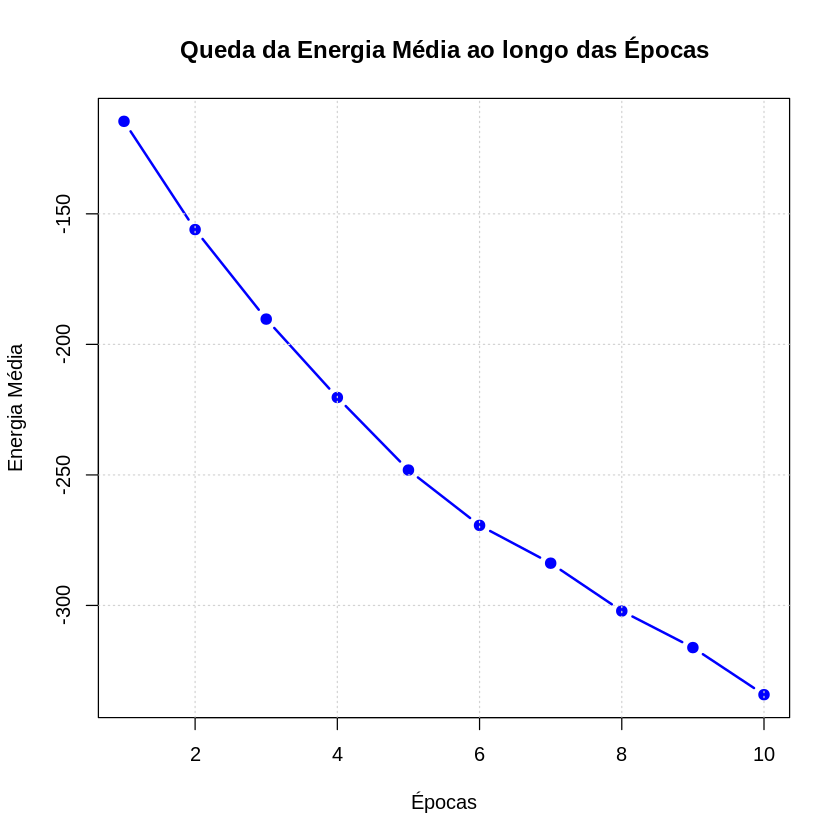

In [ ]:
# Treinamento
modelo <- contrastive.divergence(trainImages[1:1000,,],arq,1,10)

Analisando o valor da Função de energia a cada época, é possível avaliar diretamente o sucesso do aprendizado e a convergência da Restricted Boltzmann Machine (RBM), pois a queda contínua desse valor atua como uma métrica de erro (loss), indicando que a rede está ajustando seus pesos corretamente. Além disso, observar o momento em que a redução da energia desacelera e se estabiliza (erro caindo menos a acada época) permite identificar exatamente quando o modelo alcançou o equilíbrio estatístico ideal, o que ajuda a definir o critério de parada do treinamento e a diagnosticar problemas de hiperparâmetros, como uma taxa de aprendizado inadequada, caso os valores comecem a oscilar violentamente ou explodir em vez de cair de forma suave.

In [ ]:
arq$visivel.escondida

0.04752753,0.005784705,0.92539316,0.33702271,-0.02879866,-0.90890171,0.526108354,-0.61081499,0.67810957,0.42211882,⋯,-0.85062057,-0.8790567918,-0.48544964,-0.27600383,0.657151958,0.57776717,-0.188933522,0.03929663,0.016312982,-0.71903805
0.28533418,0.005480571,-0.56085731,0.09008057,0.54745099,0.44275901,0.140638146,-0.35684798,0.32419769,0.84419562,⋯,-0.52473276,0.3600704619,-0.40979962,0.29108090,0.278536120,-0.97686128,0.989988865,0.76771145,-0.540468482,0.55219800
0.04609264,0.528196416,0.25785492,-0.90102519,0.49751985,0.04462647,-0.580794340,-0.20860909,0.44778642,0.77083904,⋯,-0.88444865,-0.1051871912,0.77845467,-0.20495028,-0.399948787,-0.98949198,-0.278966823,-0.84881473,0.799522731,-0.56387470
-0.89559503,0.243642504,-0.92731286,-0.65755410,0.59025726,-0.51185059,0.154100361,0.16802773,-0.38762417,0.73318646,⋯,-0.27357126,0.5428947546,-0.77336446,-0.65082777,-0.779719905,0.34079724,-0.257149960,0.03115850,-0.683649736,0.14138545
0.44622486,-0.693552990,0.75166016,0.23727872,-0.69695286,-0.05612709,-0.538030175,-0.59512465,-0.52912863,-0.75553717,⋯,0.90662604,0.3786829584,-0.05360639,-0.32756637,-0.407385367,0.31937016,0.981509261,0.76919311,0.376753791,0.99416814
-0.68880476,0.769102898,0.97479081,0.59462898,0.15028834,0.51979590,-0.059972084,0.52969178,-0.76308391,-0.48621173,⋯,-0.12276382,-0.8528814884,0.66205607,0.10650711,-0.609700218,0.38108034,-0.864273396,0.57695865,0.064704371,-0.61739733
0.82682337,-0.132819060,0.53434533,-0.35125575,-0.75232900,0.26825256,0.186212052,-0.89555652,-0.09302410,0.02268196,⋯,0.69292508,0.4432681128,0.55210399,-0.02814812,0.790120125,0.04090923,-0.269415268,0.85068790,0.696555533,-0.99581821
0.98066835,0.024334162,-0.34398596,0.94773672,-0.93544221,0.45573495,-0.395239139,0.78217044,0.82380086,-0.49566632,⋯,-0.44811269,-0.4498229413,0.21587831,-0.54323445,0.604377653,0.18288673,-0.007779087,-0.97533257,0.985414369,0.12598522
0.57550474,-0.027853717,0.28450854,-0.83853667,0.57685371,0.06325287,-0.117107841,-0.26648697,0.86378082,-0.09749205,⋯,0.25476136,-0.5512672667,0.50432537,-0.38942285,-0.471207800,-0.22149964,0.685831837,0.99474274,0.169638577,-0.33887957
-0.96341406,-0.682671878,0.31860075,-0.49188638,-0.87975181,0.32672179,0.558809393,-0.97784505,0.46650227,-0.67994363,⋯,0.96052378,0.0682244226,-0.57512831,0.84168234,-0.033547800,-0.38818222,0.706939925,-0.67756222,-0.573107541,-0.61675528
-0.59386770,0.650714173,0.02462458,-0.57363412,0.74823277,-0.10564873,-0.127445930,-0.79868208,-0.87822201,0.82327107,⋯,-0.91860543,-0.4384443215,0.92200195,0.69424616,-0.466164579,-0.28914408,-0.003363969,0.39346482,-0.703205174,0.31217355


In [ ]:
modelo$visivel.escondida

-0.40298152,0.004387087,0.32398041,-0.12985301,-0.42880611,-1.328322364,-0.09061200,-0.81084376,0.49585339,-0.17787652,⋯,-1.05087413,-1.07920720,-0.88537014,-0.67600409,0.36475159,-0.06646528,-0.389028601,-0.55872842,-0.38672182,-0.769690910
0.08530645,-0.194124600,-0.56101685,0.08988916,0.34745065,0.045936385,-0.05937380,-0.55645291,0.12459183,0.64418961,⋯,-0.72473276,0.16324637,-0.80661887,0.09108088,0.27853607,-1.17368052,0.790383910,0.57087899,-0.74046849,0.352592815
-0.35852505,0.527191723,0.24735481,-1.03246219,0.09770499,-0.159102194,-0.78081324,-0.21096676,0.44735559,0.57083859,⋯,-1.08444909,-0.30659588,0.37881606,-0.40495173,-0.59940504,-1.18909716,-0.279545751,-0.84983216,0.59951741,-0.570260554
-1.09562995,0.056857450,-0.92781995,-0.65760165,-0.02919073,-0.712088500,-0.05139384,-0.01878384,-0.83183512,0.53345862,⋯,-0.67330447,0.54227536,-0.97325700,-0.85057653,-0.77972030,0.33849769,-0.443915528,0.01031362,-0.91388363,-0.046084851
0.22423233,-0.887947828,0.75113054,0.23708667,-0.89680853,-0.255914531,-0.73782675,-0.78960633,-0.92339028,-0.95538422,⋯,0.70683861,0.37858544,-0.25339560,-0.52735388,-0.40739448,0.27779537,0.786926188,0.76908897,0.17696639,0.777558352
-0.88693248,0.556827150,0.97470861,0.59461985,-0.24752723,0.321874436,-0.25791680,0.33134013,-0.96143713,-0.68413816,⋯,-0.32068442,-0.85308706,0.26412994,-0.09187020,-0.60970046,0.38106532,-1.062688530,0.44898825,-0.13326860,-0.815777178
0.67706884,-0.168074983,0.25521510,-0.75115803,-0.90229236,-0.081496726,0.18609229,-0.90512518,-0.10295592,0.02217384,⋯,0.54306323,0.04554758,0.35199787,-0.02838257,0.58989397,-0.35913636,-0.278982076,0.45318091,0.69633369,-1.007086954
0.35058303,-0.156563548,-0.34403114,0.58384073,-1.13702962,0.255679910,-0.59524614,0.28820943,0.60933475,-0.69570835,⋯,-0.64835462,-0.58091152,0.01129290,-0.74387894,0.60430075,0.17838820,-0.390478344,-1.30625827,0.44954437,-0.084983944
0.57549888,-0.027908691,0.23860326,-0.99466302,0.57678411,0.063206312,-0.31718812,-0.26799961,0.73074393,-0.09749307,⋯,0.25469073,-0.55128226,0.50432443,-0.38945656,-0.47122078,-0.22151752,0.609248189,0.59482311,0.16963795,-0.386035117
-1.16687344,-0.978546894,-0.10855993,-0.73138825,-1.27939211,-0.073447202,-0.44113978,-1.17764259,-0.33696849,-1.07989537,⋯,-0.03945928,-0.53712741,-0.97520322,0.04153149,-0.61574084,-1.19337742,-0.092475282,-0.67772814,-0.97315295,-1.497608635
-0.60285145,0.473258212,-0.01182675,-0.57387963,0.73297761,-0.314592147,-0.13687238,-0.79871249,-0.88442724,0.81426663,⋯,-0.93373143,-0.63841416,0.70245727,0.68526417,-0.49614633,-0.49962957,-0.003467003,0.18298556,-0.71218609,0.312166293


In [ ]:
exemplos.teste <- testImages[1:10,,]
dim(exemplos.teste[1,,])

[1] 28 28

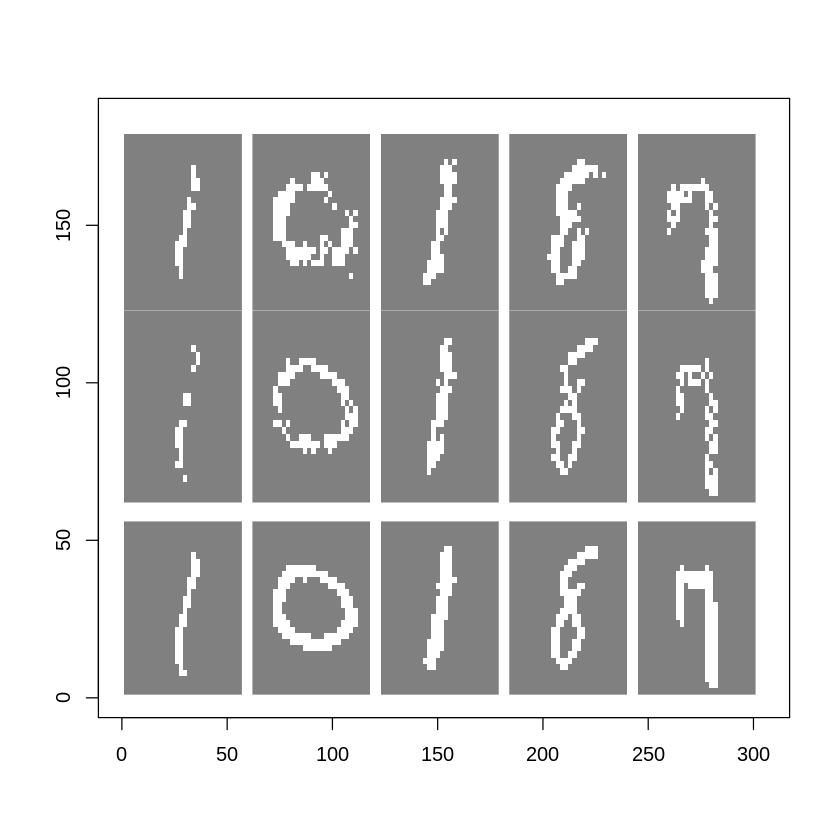

In [ ]:
testa.digitos(modelo, testImages[sample(nrow(testImages),5),,], taxa.ruido = 0.3)